# Plot Storm Densities - Urban v Non-urban

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


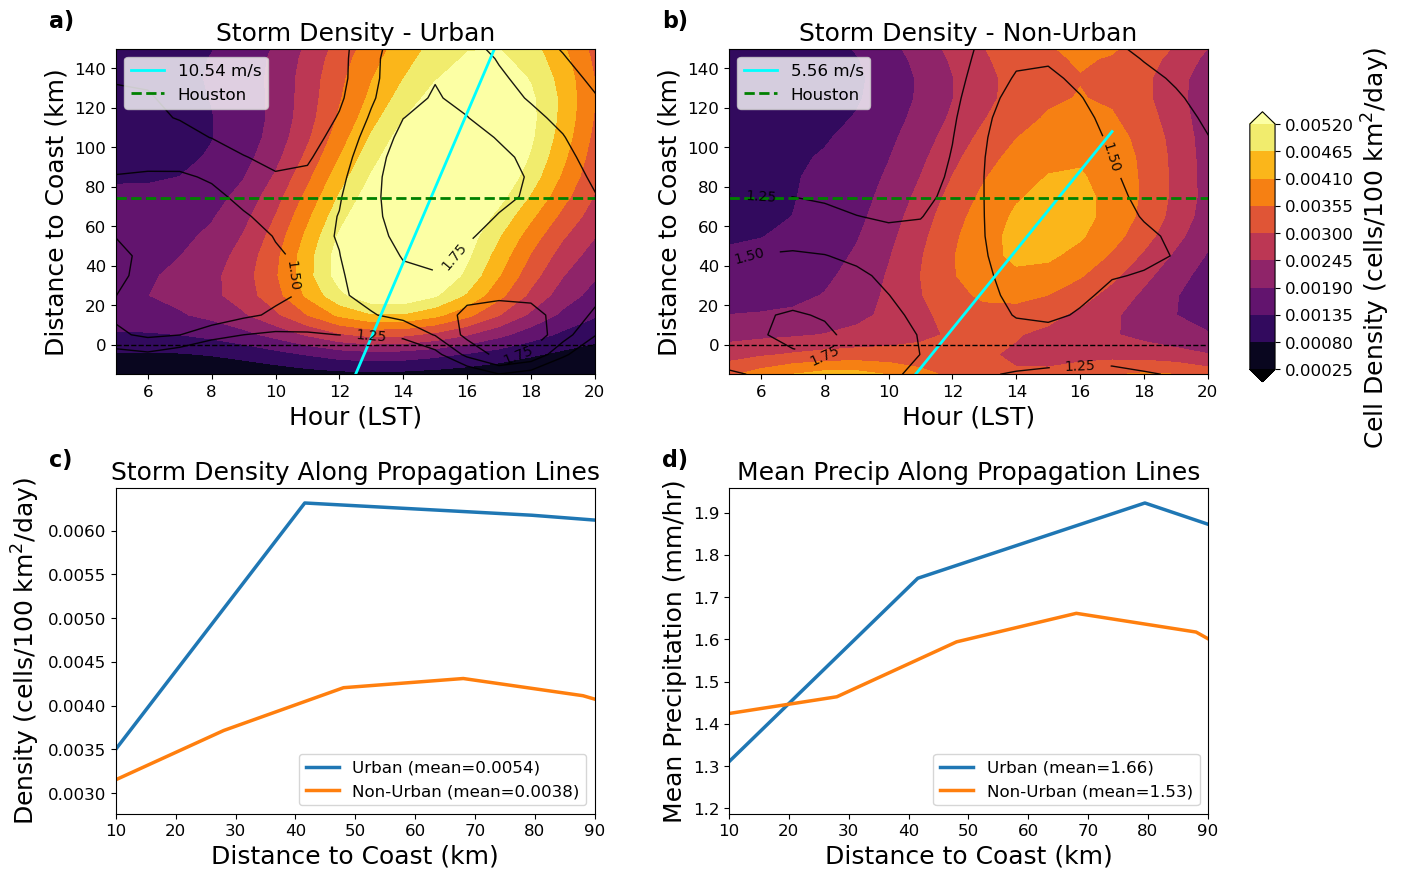

Saved figure: Plot_Directory\Combined_Urban_NonUrban_Hovmoller_AlongLines.png
Saved csv: Plot_Directory\AlongLines_Urban_vs_NonUrban_Density_and_Precip.csv
Urban hovmöller rainfall variable used: mean_precip_smoothed
Non-urban hovmöller rainfall variable used: mean_precip_smoothed
Urban precip variable used: mean_precip_smoothed
Non-urban precip variable used: mean_precip_smoothed
Urban raw fitted line speed: 10.54 m/s
Non-urban raw fitted line speed: 9.26 m/s
Urban plotted line speed: 10.54 m/s
Non-urban plotted line speed: 5.56 m/s
Urban plotted slope: 37.93 km/hr
Non-urban plotted slope: 20.00 km/hr
Urban plotted intercept: -489.48 km
Non-urban plotted intercept: -231.97 km
Urban plotted line distances:
[-110.17241379  155.34482759]
Non-urban plotted line distances:
[-31.96969697 108.03030303]


In [1]:
# -*- coding: utf-8 -*-
# Combined 2x2 figure:
# Top row   -> Urban / Non-Urban storm density hovmöllers with rainfall contours
# Bottom row-> Storm density and mean precip along respective propagation lines

import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Plot style
# --------------------------------------------------
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

# --------------------------------------------------
# Files
# --------------------------------------------------
f_urban = 'Counts_and_ArealDensities_Urban_Smoothed_rawrf.nc'
f_non   = 'Counts_and_ArealDensities_Nonurban_Smoothed_rawrf.nc'

# --------------------------------------------------
# Common settings
# --------------------------------------------------
DIST_SLICE    = slice(155, -15)
FIT_WINDOW_KM = 50
FD_VAR        = 'areal_density_per_100km2_day_smoothed'

# For bottom panels
XLIM_DIST = (10, 90)

# Output
outdir = "Plot_Directory"
os.makedirs(outdir, exist_ok=True)
out_png = os.path.join(outdir, "Combined_Urban_NonUrban_Hovmoller_AlongLines.png")
out_csv = os.path.join(outdir, "AlongLines_Urban_vs_NonUrban_Density_and_Precip.csv")

# --------------------------------------------------
# Along-path sampling windows
# --------------------------------------------------
URB_TIME_MIN = 10.0
URB_TIME_MAX = 17.0
URB_STEP     = 1.0

NON_TIME_MIN = 10.0
NON_TIME_MAX = 17.0
NON_STEP     = 1.0

# --------------------------------------------------
# Propagation-line choices
# --------------------------------------------------
# Urban
URBAN_USE_MANUAL = True
URB_SLOPE_MULT   = 1.0
URB_PIVOT_HR     = 15.0
URB_SHIFT_KM     = 0.0

# Non-urban
NON_USE_MANUAL = True
NON_SLOPE_MULT = 0.6
NON_PIVOT_HR   = 15.0
NON_SHIFT_KM   = 0.0

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def fit_line_from_fd(fd, hours, dist_km, window_km=50):
    peak_idx_flat = np.nanargmax(fd)
    peak_dist_idx, _ = np.unravel_index(peak_idx_flat, fd.shape)

    fit_mask = (
        (dist_km >= dist_km[peak_dist_idx] - window_km) &
        (dist_km <= dist_km[peak_dist_idx] + window_km)
    )

    distances_fit = dist_km[fit_mask]

    peak_hours = []

    for di in np.where(fit_mask)[0]:
        time_profile = fd[di, :]

        if np.all(~np.isfinite(time_profile)):
            peak_hours.append(np.nan)
            continue

        h_idx = np.nanargmax(time_profile)
        peak_hours.append(hours[h_idx])

    peak_hours = np.asarray(peak_hours)

    valid = np.isfinite(distances_fit) & np.isfinite(peak_hours)
    distances_fit = distances_fit[valid]
    peak_hours = peak_hours[valid]

    if len(distances_fit) < 2:
        raise ValueError(
            "Not enough valid distance bins to fit a propagation line. "
            "Try increasing FIT_WINDOW_KM."
        )

    # hours = theta * distance + intercept_time
    theta, intercept_time = np.polyfit(distances_fit, peak_hours, 1)

    # Avoid hard crash if theta is nearly zero, but print warning
    if np.isclose(theta, 0):
        print("WARNING: theta is close to zero. Raw fitted line may be nearly vertical.")
        print("Distances used in raw fit:")
        print(distances_fit)
        print("Peak hours used in raw fit:")
        print(peak_hours)

    slope_dist_per_hr = 1 / theta
    intercept_dist = -intercept_time / theta
    effective_speed = slope_dist_per_hr * 1000 / 3600  # m/s

    return slope_dist_per_hr, intercept_dist, effective_speed


def interp_1d(x, y, xq):
    x = np.asarray(x)
    y = np.asarray(y)
    xq = np.asarray(xq)

    out = np.full_like(xq, np.nan, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    if np.sum(valid) < 2:
        return out

    x_valid = x[valid]
    y_valid = y[valid]

    order = np.argsort(x_valid)
    x_valid = x_valid[order]
    y_valid = y_valid[order]

    ok = np.isfinite(xq) & (xq >= x_valid.min()) & (xq <= x_valid.max())

    if np.any(ok):
        out[ok] = np.interp(xq[ok], x_valid, y_valid)

    return out


def build_line_from_fit(slope_fit, intercept_fit, use_manual,
                        slope_mult=1.0, pivot_hr=15.0, shift_km=0.0):
    if not use_manual:
        slope_line = slope_fit
        intercept_line = intercept_fit
    else:
        slope_line = slope_fit * slope_mult

        dist_at_pivot_fit = slope_fit * pivot_hr + intercept_fit
        dist_at_pivot_manual = dist_at_pivot_fit + shift_km

        intercept_line = dist_at_pivot_manual - slope_line * pivot_hr

    speed_ms = slope_line * 1000 / 3600

    return slope_line, intercept_line, speed_ms


def pick_precip_var(ds):
    for cand in [
        'mean_precip_smoothed',
        'mean_precip',
        'raw_rainfall_binned_smoothed',
        'raw_rainfall_binned'
    ]:
        if cand in ds.variables:
            return cand

    raise KeyError(
        "No precip/rain variable found. Expected one of: "
        "mean_precip_smoothed / mean_precip / "
        "raw_rainfall_binned_smoothed / raw_rainfall_binned"
    )


def pick_rr_var_for_hovmoller(ds):
    for cand in [
        'raw_rainfall_binned_smoothed',
        'raw_rainfall_binned',
        'mean_precip_smoothed',
        'mean_precip'
    ]:
        if cand in ds.variables:
            return cand

    raise KeyError(
        "No rainfall variable found for hovmöller. Expected one of: "
        "raw_rainfall_binned_smoothed / raw_rainfall_binned / "
        "mean_precip_smoothed / mean_precip"
    )


def load_hovmoller_case(ds):
    fd = ds[FD_VAR].values
    hours = ds['hour'].values
    dist_km = ds['distance_km'].values

    rr_var = pick_rr_var_for_hovmoller(ds)
    rr = ds[rr_var].values

    slope_dist_per_hr, intercept_dist, effective_speed = fit_line_from_fd(
        fd,
        hours,
        dist_km,
        window_km=FIT_WINDOW_KM
    )

    return {
        "fd": fd,
        "rr": rr,
        "hours": hours,
        "dist_km": dist_km,
        "rr_var": rr_var,
        "slope": slope_dist_per_hr,
        "intercept": intercept_dist,
        "speed": effective_speed
    }


def sample_along_line_respective(ds, slope_line, intercept_line,
                                 tmin, tmax, dt, varname,
                                 dist_slice=DIST_SLICE):
    """
    Samples var(distance, hour) along:

        distance = slope_line * hour + intercept_line

    Returns arrays sorted by distance:
        x_dist, y_var, use_hours
    """

    ds = ds.sel(distance_km=dist_slice)

    hours = ds["hour"].values
    dist_km = ds["distance_km"].values
    arr = ds[varname].values  # expected shape: distance, hour

    target_hours = np.arange(tmin, tmax + 1e-6, dt)

    idx_hours = np.array([
        np.nanargmin(np.abs(hours - h)) for h in target_hours
    ], dtype=int)

    use_hours = hours[idx_hours]
    path_dist = slope_line * use_hours + intercept_line

    # Make sure distance is increasing for interpolation
    if dist_km[0] > dist_km[-1]:
        dist_inc = dist_km[::-1]
        arr_inc = arr[::-1, :]
    else:
        dist_inc = dist_km
        arr_inc = arr

    along = np.full_like(use_hours, np.nan, dtype=float)

    for k, j in enumerate(idx_hours):
        profile = arr_inc[:, j]

        along[k] = interp_1d(
            dist_inc,
            profile,
            np.array([path_dist[k]])
        )[0]

    order = np.argsort(path_dist)

    return path_dist[order], along[order], use_hours[order]


# --------------------------------------------------
# Load datasets
# --------------------------------------------------
dsU = xr.open_dataset(f_urban).sel(distance_km=DIST_SLICE)
dsN = xr.open_dataset(f_non).sel(distance_km=DIST_SLICE)

# Hovmöller cases
urban_hov = load_hovmoller_case(dsU)
non_hov   = load_hovmoller_case(dsN)

# Precip variables for bottom panels
pU = pick_precip_var(dsU)
pN = pick_precip_var(dsN)

# --------------------------------------------------
# Fit baseline lines separately
# --------------------------------------------------
slope_fit_U, intercept_fit_U, speed_fit_U = fit_line_from_fd(
    dsU[FD_VAR].values,
    dsU["hour"].values,
    dsU["distance_km"].values,
    window_km=FIT_WINDOW_KM
)

slope_fit_N, intercept_fit_N, speed_fit_N = fit_line_from_fd(
    dsN[FD_VAR].values,
    dsN["hour"].values,
    dsN["distance_km"].values,
    window_km=FIT_WINDOW_KM
)

# --------------------------------------------------
# Build respective propagation lines
# --------------------------------------------------
slope_line_U, intercept_line_U, speed_line_U = build_line_from_fit(
    slope_fit_U,
    intercept_fit_U,
    use_manual=URBAN_USE_MANUAL,
    slope_mult=URB_SLOPE_MULT,
    pivot_hr=URB_PIVOT_HR,
    shift_km=URB_SHIFT_KM
)

slope_line_N, intercept_line_N, speed_line_N = build_line_from_fit(
    slope_fit_N,
    intercept_fit_N,
    use_manual=NON_USE_MANUAL,
    slope_mult=NON_SLOPE_MULT,
    pivot_hr=NON_PIVOT_HR,
    shift_km=NON_SHIFT_KM
)

# --------------------------------------------------
# Sample along respective lines
# --------------------------------------------------
# Density
xU_fd, yU_fd, _ = sample_along_line_respective(
    dsU,
    slope_line_U,
    intercept_line_U,
    URB_TIME_MIN,
    URB_TIME_MAX,
    URB_STEP,
    varname=FD_VAR
)

xN_fd, yN_fd, _ = sample_along_line_respective(
    dsN,
    slope_line_N,
    intercept_line_N,
    NON_TIME_MIN,
    NON_TIME_MAX,
    NON_STEP,
    varname=FD_VAR
)

# Precipitation
xU_pr, yU_pr, _ = sample_along_line_respective(
    dsU,
    slope_line_U,
    intercept_line_U,
    URB_TIME_MIN,
    URB_TIME_MAX,
    URB_STEP,
    varname=pU
)

xN_pr, yN_pr, _ = sample_along_line_respective(
    dsN,
    slope_line_N,
    intercept_line_N,
    NON_TIME_MIN,
    NON_TIME_MAX,
    NON_STEP,
    varname=pN
)

meanU_fd = np.nanmean(yU_fd)
meanN_fd = np.nanmean(yN_fd)
meanU_pr = np.nanmean(yU_pr)
meanN_pr = np.nanmean(yN_pr)

# --------------------------------------------------
# Levels for top row
# --------------------------------------------------
dlevels = np.linspace(0.00025, 0.0052, 10)
rr_levels = [1.25, 1.5, 1.75]

# --------------------------------------------------
# Create combined 2x2 figure
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax00, ax01 = axes[0, 0], axes[0, 1]
ax10, ax11 = axes[1, 0], axes[1, 1]

# --------------------------------------------------
# Top-left: Urban Hovmöller
# --------------------------------------------------
cf = ax00.contourf(
    urban_hov["hours"],
    urban_hov["dist_km"],
    urban_hov["fd"],
    levels=dlevels,
    cmap='inferno',
    extend='both'
)

cs = ax00.contour(
    urban_hov["hours"],
    urban_hov["dist_km"],
    urban_hov["rr"],
    levels=rr_levels,
    colors='black',
    linewidths=1.0,
    alpha=0.9
)

ax00.clabel(cs, inline=True, fontsize=10, fmt="%.2f")

# IMPORTANT:
# Plot the built/respective urban line, not the raw urban_hov["slope"] line.
line_times = np.array([URB_TIME_MIN, URB_TIME_MAX])
line_distances = slope_line_U * line_times + intercept_line_U

ax00.plot(
    line_times,
    line_distances,
    color='cyan',
    linewidth=2,
    label=f'{speed_line_U:.2f} m/s'
)

ax00.axhline(0, color='k', linestyle='--', linewidth=1)
ax00.axhline(74.3, color='g', linestyle='--', linewidth=2, label='Houston')

ax00.set_xlim(5, 20)
ax00.set_ylim(-15, 150)
ax00.set_xlabel('Hour (LST)')
ax00.set_ylabel('Distance to Coast (km)')
ax00.set_title("Storm Density - Urban")
ax00.legend(loc='upper left', frameon=True, fontsize=12)

# --------------------------------------------------
# Top-right: Non-urban Hovmöller
# --------------------------------------------------
cf = ax01.contourf(
    non_hov["hours"],
    non_hov["dist_km"],
    non_hov["fd"],
    levels=dlevels,
    cmap='inferno',
    extend='both'
)

cs = ax01.contour(
    non_hov["hours"],
    non_hov["dist_km"],
    non_hov["rr"],
    levels=rr_levels,
    colors='black',
    linewidths=1.0,
    alpha=0.9
)

ax01.clabel(cs, inline=True, fontsize=10, fmt="%.2f")

# IMPORTANT:
# Plot the built/respective non-urban line, not the raw non_hov["slope"] line.
line_times = np.array([NON_TIME_MIN, NON_TIME_MAX])
line_distances = slope_line_N * line_times + intercept_line_N

ax01.plot(
    line_times,
    line_distances,
    color='cyan',
    linewidth=2,
    label=f'{speed_line_N:.2f} m/s'
)

ax01.axhline(0, color='k', linestyle='--', linewidth=1)
ax01.axhline(74.3, color='g', linestyle='--', linewidth=2, label='Houston')

ax01.set_xlim(5, 20)
ax01.set_ylim(-15, 150)
ax01.set_xlabel('Hour (LST)')
ax01.set_ylabel('Distance to Coast (km)')
ax01.set_title("Storm Density - Non-Urban")
ax01.legend(loc='upper left', frameon=True, fontsize=12)

# --------------------------------------------------
# Bottom-left: Storm density along propagation lines
# --------------------------------------------------
ax10.plot(
    xU_fd,
    yU_fd,
    linewidth=2.5,
    label=f"Urban (mean={meanU_fd:.4f})"
)

ax10.plot(
    xN_fd,
    yN_fd,
    linewidth=2.5,
    label=f"Non-Urban (mean={meanN_fd:.4f})"
)

ax10.axvline(0, color="k", linestyle="--", linewidth=1)

ax10.set_xlim(*XLIM_DIST)
ax10.set_xlabel("Distance to Coast (km)")
ax10.set_ylabel("Density (cells/100 km$^2$/day)")
ax10.set_title("Storm Density Along Propagation Lines")
ax10.legend(loc='lower right', frameon=True, fontsize=12)

# --------------------------------------------------
# Bottom-right: Mean precip along propagation lines
# --------------------------------------------------
ax11.plot(
    xU_pr,
    yU_pr,
    linewidth=2.5,
    label=f"Urban (mean={meanU_pr:.2f})"
)

ax11.plot(
    xN_pr,
    yN_pr,
    linewidth=2.5,
    label=f"Non-Urban (mean={meanN_pr:.2f})"
)

ax11.axvline(0, color="k", linestyle="--", linewidth=1)

ax11.set_xlim(*XLIM_DIST)
ax11.set_xlabel("Distance to Coast (km)")
ax11.set_ylabel("Mean Precipitation (mm/hr)")
ax11.set_title("Mean Precip Along Propagation Lines")
ax11.legend(loc='lower right', frameon=True, fontsize=12)

# --------------------------------------------------
# Panel labels outside axes
# --------------------------------------------------
panel_labels = {
    ax00: "a)",
    ax01: "b)",
    ax10: "c)",
    ax11: "d)"
}

for ax, lab in panel_labels.items():
    ax.text(
        -0.14,
        1.05,
        lab,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='bottom',
        ha='left',
        clip_on=False
    )

# --------------------------------------------------
# Layout and colorbar
# --------------------------------------------------
fig.subplots_adjust(
    left=0.10,
    right=0.88,
    top=0.93,
    bottom=0.08,
    wspace=0.28,
    hspace=0.35
)

# Colorbar for top row
cax = fig.add_axes([0.91, 0.56, 0.018, 0.30])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('Cell Density (cells/100 km$^2$/day)')

# --------------------------------------------------
# Save combined figure
# --------------------------------------------------
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# Save CSV on common distance axis
# --------------------------------------------------
dist_common_min = np.nanmax([
    XLIM_DIST[0],
    np.nanmin([np.nanmin(xU_fd), np.nanmin(xN_fd), np.nanmin(xU_pr), np.nanmin(xN_pr)])
])

dist_common_max = np.nanmin([
    XLIM_DIST[1],
    np.nanmax([np.nanmax(xU_fd), np.nanmax(xN_fd), np.nanmax(xU_pr), np.nanmax(xN_pr)])
])

dist_common = np.linspace(dist_common_min, dist_common_max, 300)

df = pd.DataFrame({
    "distance_km": dist_common,
    "urban_density_along_line": interp_1d(xU_fd, yU_fd, dist_common),
    "nonurban_density_along_line": interp_1d(xN_fd, yN_fd, dist_common),
    "urban_precip_along_line": interp_1d(xU_pr, yU_pr, dist_common),
    "nonurban_precip_along_line": interp_1d(xN_pr, yN_pr, dist_common),
})

df.to_csv(out_csv, index=False)

# --------------------------------------------------
# Print summary
# --------------------------------------------------
print(f"Saved figure: {out_png}")
print(f"Saved csv: {out_csv}")

print(f"Urban hovmöller rainfall variable used: {urban_hov['rr_var']}")
print(f"Non-urban hovmöller rainfall variable used: {non_hov['rr_var']}")

print(f"Urban precip variable used: {pU}")
print(f"Non-urban precip variable used: {pN}")

print(f"Urban raw fitted line speed: {urban_hov['speed']:.2f} m/s")
print(f"Non-urban raw fitted line speed: {non_hov['speed']:.2f} m/s")

print(f"Urban plotted line speed: {speed_line_U:.2f} m/s")
print(f"Non-urban plotted line speed: {speed_line_N:.2f} m/s")

print(f"Urban plotted slope: {slope_line_U:.2f} km/hr")
print(f"Non-urban plotted slope: {slope_line_N:.2f} km/hr")

print(f"Urban plotted intercept: {intercept_line_U:.2f} km")
print(f"Non-urban plotted intercept: {intercept_line_N:.2f} km")

print("Urban plotted line distances:")
print(slope_line_U * np.array([URB_TIME_MIN, URB_TIME_MAX]) + intercept_line_U)

print("Non-urban plotted line distances:")
print(slope_line_N * np.array([NON_TIME_MIN, NON_TIME_MAX]) + intercept_line_N)